HUGGING FACE EMBEDDINGS PROJECT

Loading model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!
Model: all-MiniLM-L6-v2
Embedding size: 384 dimensions

1. FIRST EMBEDDING

Sentence:
I love learning about Artificial Intelligence.

Embedding shape:
(384,)

First 10 embedding values:
[ 0.01634455 -0.0765703   0.04107474  0.01962832  0.05804764 -0.05071755
  0.03889348  0.03076576  0.05800403  0.06948569]

2. MULTIPLE SENTENCE EMBEDDINGS

Number of sentences: 5
Embedding matrix shape: (5, 384)

3. COSINE SIMILARITY

Similarity Matrix:


,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00



4. SPECIFIC SIMILARITY COMPARISON

Sentence 1: I love dogs
Sentence 2: I like puppies

Cosine Similarity: 0.7053

5. PCA 2D VISUALIZATION


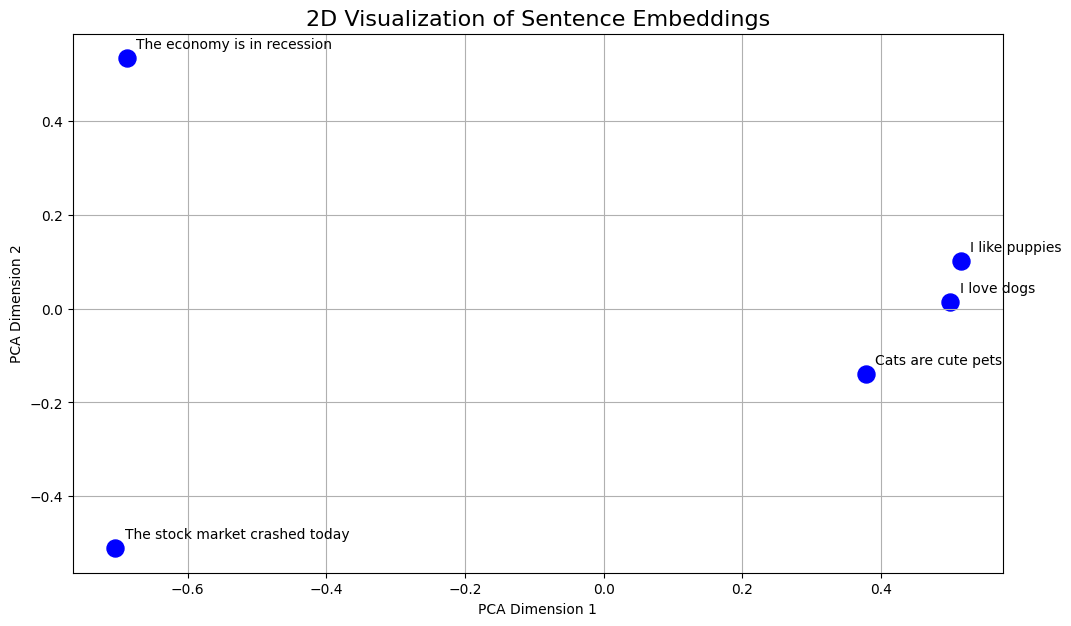


6. MINI SEMANTIC SEARCH ENGINE

Documents in database: 10

Creating document embeddings...
Document embeddings created!
Shape: (10, 384)

----------------------------------------------------------------------
QUERY:
Tell me about AI and neural networks

TOP RESULTS:
----------------------------------------------------------------------
1. Score: 0.6147
   Neural networks are inspired by the human brain.
2. Score: 0.5471
   Artificial intelligence is used in many modern applications.
3. Score: 0.5342
   Deep learning uses neural networks with many layers.


----------------------------------------------------------------------
QUERY:
What is the capital of France?

TOP RESULTS:
----------------------------------------------------------------------
1. Score: 0.8243
   Paris is the capital city of France.
2. Score: 0.1174
   Football is one of the most popular sports in the world.
3. Score: 0.1020
   Python is a popular programming language for AI.


-------------------------------------

In [5]:
# ================================================================
# GENERATING EMBEDDINGS USING HUGGING FACE
# FREE MODEL + COSINE SIMILARITY + PCA + SEMANTIC SEARCH
# Google Colab - One Cell
# ================================================================

# ------------------------------------------------
# 1. INSTALL REQUIRED LIBRARIES
# ------------------------------------------------

!pip install -q sentence-transformers scikit-learn matplotlib pandas

# ------------------------------------------------
# 2. IMPORT LIBRARIES
# ------------------------------------------------

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("HUGGING FACE EMBEDDINGS PROJECT")
print("=" * 70)

# ------------------------------------------------
# 3. LOAD FREE HUGGING FACE MODEL
# ------------------------------------------------

print("\nLoading model...")

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully!")
print("Model: all-MiniLM-L6-v2")
print("Embedding size: 384 dimensions")

# ------------------------------------------------
# 4. GENERATE YOUR FIRST EMBEDDING
# ------------------------------------------------

print("\n" + "=" * 70)
print("1. FIRST EMBEDDING")
print("=" * 70)

sentence = "I love learning about Artificial Intelligence."

embedding = model.encode(sentence)

print("\nSentence:")
print(sentence)

print("\nEmbedding shape:")
print(embedding.shape)

print("\nFirst 10 embedding values:")
print(embedding[:10])

# ------------------------------------------------
# 5. GENERATE EMBEDDINGS FOR MULTIPLE SENTENCES
# ------------------------------------------------

print("\n" + "=" * 70)
print("2. MULTIPLE SENTENCE EMBEDDINGS")
print("=" * 70)

sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("\nNumber of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

# ------------------------------------------------
# 6. COSINE SIMILARITY
# ------------------------------------------------

print("\n" + "=" * 70)
print("3. COSINE SIMILARITY")
print("=" * 70)

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

print("\nSimilarity Matrix:")
display(df.round(2))

# ------------------------------------------------
# 7. COMPARE TWO SPECIFIC SENTENCES
# ------------------------------------------------

print("\n" + "=" * 70)
print("4. SPECIFIC SIMILARITY COMPARISON")
print("=" * 70)

sentence1 = "I love dogs"
sentence2 = "I like puppies"

embedding1 = model.encode([sentence1])
embedding2 = model.encode([sentence2])

score = cosine_similarity(
    embedding1,
    embedding2
)[0][0]

print("\nSentence 1:", sentence1)
print("Sentence 2:", sentence2)
print(f"\nCosine Similarity: {score:.4f}")

# ------------------------------------------------
# 8. PCA VISUALIZATION
# ------------------------------------------------

print("\n" + "=" * 70)
print("5. PCA 2D VISUALIZATION")
print("=" * 70)

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(12, 7))

plt.scatter(
    reduced_embeddings[:, 0],
    reduced_embeddings[:, 1],
    s=150,
    color="blue"
)

for i, sentence in enumerate(sentences):
    plt.annotate(
        sentence,
        (
            reduced_embeddings[i, 0],
            reduced_embeddings[i, 1]
        ),
        fontsize=10,
        xytext=(7, 7),
        textcoords="offset points"
    )

plt.title(
    "2D Visualization of Sentence Embeddings",
    fontsize=16
)

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.grid(True)
plt.show()

# ------------------------------------------------
# 9. MINI SEMANTIC SEARCH DATABASE
# ------------------------------------------------

print("\n" + "=" * 70)
print("6. MINI SEMANTIC SEARCH ENGINE")
print("=" * 70)

documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France.",
    "Artificial intelligence is used in many modern applications.",
    "Neural networks are inspired by the human brain.",
    "Python can be used for data science and machine learning.",
    "Football is one of the most popular sports in the world."
]

print("\nDocuments in database:", len(documents))

# ------------------------------------------------
# 10. CREATE DOCUMENT EMBEDDINGS
# ------------------------------------------------

print("\nCreating document embeddings...")

doc_embeddings = model.encode(documents)

print("Document embeddings created!")
print("Shape:", doc_embeddings.shape)

# ------------------------------------------------
# 11. SEMANTIC SEARCH FUNCTION
# ------------------------------------------------

def semantic_search(query, top_k=3):
    # Convert query into embedding
    query_embedding = model.encode([query])

    # Calculate similarity between query and documents
    scores = cosine_similarity(
        query_embedding,
        doc_embeddings
    )[0]

    # Sort from highest similarity to lowest
    ranked_indices = scores.argsort()[::-1][:top_k]

    print("\n" + "-" * 70)
    print("QUERY:")
    print(query)

    print("\nTOP RESULTS:")
    print("-" * 70)

    for rank, idx in enumerate(ranked_indices, start=1):
        print(
            f"{rank}. Score: {scores[idx]:.4f}"
        )
        print(
            f"   {documents[idx]}"
        )
    print()

# ------------------------------------------------
# 12. TEST SEMANTIC SEARCH
# ------------------------------------------------

semantic_search(
    "Tell me about AI and neural networks"
)

semantic_search(
    "What is the capital of France?"
)

semantic_search(
    "How does machine learning work?"
)

semantic_search(
    "I want to know about programming"
)

semantic_search(
    "Tell me about sports"
)

# ------------------------------------------------
# 13. TRY YOUR OWN QUERY (Non-interactive for Colab safety)
# ------------------------------------------------

print("\n" + "=" * 70)
print("7. TRY YOUR OWN QUERY")
print("=" * 70)

# We'll use a static query here to avoid blocking execution with input()
user_query = "I love writing Python code for data science"
print(f"Executing search for static query: '{user_query}'")

semantic_search(
    user_query,
    top_k=3
)

# ------------------------------------------------
# 14. FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("PROJECT COMPLETED!")
print("=" * 70)

print("""
You learned:

1. What text embeddings are
2. How to use a free Hugging Face model
3. How to generate embeddings
4. How to calculate cosine similarity
5. How to visualize embeddings using PCA
6. How semantic search works
7. How to build a mini semantic search engine

Model used:
all-MiniLM-L6-v2

Embedding size:
384 dimensions

No API key required.
No paid API required.
""")

print("=" * 70)